In [1]:
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2
# Recarga automáticamente todos los módulos importados.

In [3]:
import numpy as np
import mne
from typing import List, Tuple, Union

# 1) Montaje reducido para test
montage_list_1 = ["A", "B"]
montage_list_2 = ["C", "D"]

# 2) Creamos datos sintéticos
n_samp = 5
data = np.vstack([
    np.sin(np.linspace(0,10,n_samp)),  # canal "A"
    np.cos(np.linspace(0,10,n_samp)),  # canal "B"
    np.ones(n_samp)*2,                 # canal "C"
    np.zeros(n_samp)                   # canal "D"
])
print("Data shape:", data.shape)  # (4, 10)
print("Data: ", data)

ch_names = ["A","B","C","D"]
info = mne.create_info(ch_names, sfreq=256.0)
#print info
# print("Info:", info)  # Info object with channel names and sampling frequency

# 3) Generamos un RawArray
raw_test = mne.io.RawArray(data, info)
print("Raw data: ", raw_test.get_data())  # Datos del RawArray
print("Raw ch_names:", raw_test.ch_names)  # Nombres de los canales
print("Raw times:", raw_test.times)  # Tiempos de los datos
print("Raw info:", raw_test.info)  # Información del RawArray
print("Raw info ch_names:", raw_test.info['ch_names'])  # Nombres de los canales
print("Raw info sfreq:", raw_test.info['sfreq'])  # Frecuencia de muestreo
print("Raw info nchan:", raw_test.info['nchan'])  # Número de canales
print("Raw info meas_date:", raw_test.info['meas_date'])  # Fecha de medición
print("Raw info highpass:", raw_test.info['highpass'])  # Frecuencia de corte alta
print("Raw info lowpass:", raw_test.info['lowpass'])  # Frecuencia de corte baja
print("Raw info ch_names:", raw_test.info['ch_names'])  # Nombres de los canales
print("Raw info nchan:", raw_test.info['nchan'])  # Número de canales
print("Raw info highpass:", raw_test.info['highpass'])  # Frecuencia de corte alta

# 4) Función adaptada para el test:
def get_channels_from_raw_test(
    raw: mne.io.BaseRaw
) -> Tuple[bool, Union[int, np.ndarray]]:
    # Intentamos extraer montajes reducidos
    try:
        sig1 = raw.get_data(picks=montage_list_1)
        sig2 = raw.get_data(picks=montage_list_2)
    except Exception as e:
        print("Error:", e)
        return True, 0
    return False, sig1 - sig2

# 5) Ejecutamos el test
flag, diff = get_channels_from_raw_test(raw_test)
print("Flag:", flag)            # debe ser False
print("Shape diff:", diff.shape)  # (2, 1000)
print("First 5 samples diff A-C:", diff[0, :5])  


Data shape: (4, 5)
Data:  [[ 0.          0.59847214 -0.95892427  0.93799998 -0.54402111]
 [ 1.         -0.80114362  0.28366219  0.34663532 -0.83907153]
 [ 2.          2.          2.          2.          2.        ]
 [ 0.          0.          0.          0.          0.        ]]
Creating RawArray with float64 data, n_channels=4, n_times=5
    Range : 0 ... 4 =      0.000 ...     0.016 secs
Ready.
Raw data:  [[ 0.          0.59847214 -0.95892427  0.93799998 -0.54402111]
 [ 1.         -0.80114362  0.28366219  0.34663532 -0.83907153]
 [ 2.          2.          2.          2.          2.        ]
 [ 0.          0.          0.          0.          0.        ]]
Raw ch_names: ['A', 'B', 'C', 'D']
Raw times: [0.         0.00390625 0.0078125  0.01171875 0.015625  ]
Raw info: <Info | 7 non-empty values
 bads: []
 ch_names: A, B, C, D
 chs: 4 misc
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 4
 projs: []
 sfreq: 256.0 Hz
>
Raw info ch_names: ['A',

In [4]:
# dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaauj/s004_2012/01_tcp_ar/aaaaaauj_s004_t000.edf
# dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaedy/s002_2004/02_tcp_le/aaaaaedy_s002_t001.edf
# dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaedy/s003_2004/02_tcp_le/aaaaaedy_s003_t000.edf
from data_reader_2023 import *
import mne


data_path = "dataset/tuh_eeg_seizure/v2.0.3/edf/train/aaaaaauj/s004_2012/01_tcp_ar/aaaaaauj_s004_t000.edf"
# 1. Cargo el raw (sin precargar datos en RAM)
raw = mne.io.read_raw_edf(data_path,preload=True, verbose='warning')

flag_wrong: bool
signals: np.ndarray
flag_wrong, signals = get_channels_from_raw(raw)


# # 2. Veo resumen de canales y sampling rate
# print(raw.info['ch_names'])   # ej. ['EEG FP1-REF', 'EEG F7-REF', …]
# print(raw.info['sfreq'])      # ej. 256.0 Hz

# # 3. Cargo datos en memoria
# raw.load_data()

# # 4. Miro el array numpy
# data = raw.get_data()         # shape (n_chanels, n_times)
# print(data.shape) 


# # 5. Inspecciono un fragmento y sus unidades
# print(data[0, :5])            # primeras 5 muestras del canal 0
# # (ya están en V, p. ej. [ 0.00000123, 0.00000127, … ])



ch_names: ['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG A1-REF', 'EEG A2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF', 'EEG ROC-REF', 'EEG LOC-REF', 'EEG EKG1-REF', 'EEG T1-REF', 'EEG T2-REF', 'PHOTIC-REF', 'IBI', 'BURSTS', 'SUPPR']


Número de canales : 30
Frecuencia muestreo: 250.0 Hz
Duración          : 1245.0 s
Tipos de canal    : ['eeg']
Nombres de canal  : ['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF'] …

Estadísticas (primeros 5 canales):
  EEG FP1-REF – µ=0.000, σ=0.000
  EEG FP2-REF – µ=0.000, σ=0.000
  EEG F3-REF – µ=0.000, σ=0.000
  EEG F4-REF – µ=0.000, σ=0.000
  EEG C3-REF – µ=0.000, σ=0.000


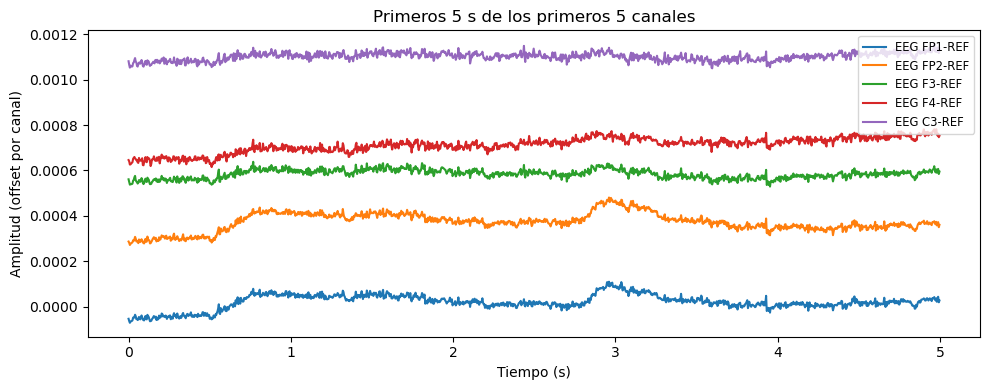

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/home/dell/anaconda3/envs/tesis_eeg/lib/python3.10/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


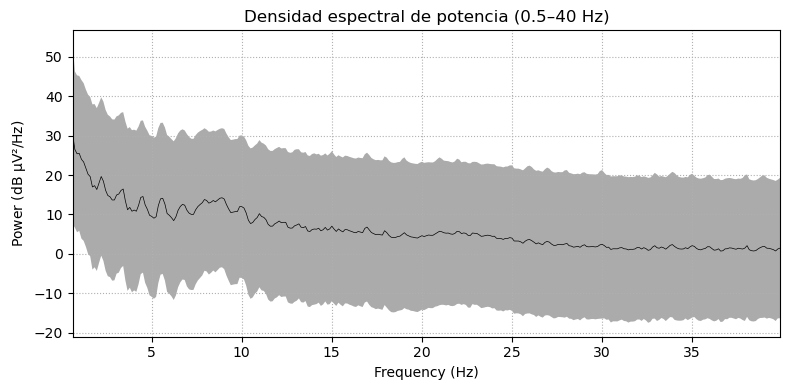

Sampling rate: 250.0


In [5]:
# 2. Llamada a la nueva función
info = summarize_raw(raw)
# 3. Accede al diccionario si lo necesitas
print("Sampling rate:", info["sfreq"])

In [6]:
a: int = sumaAlCuadrado(2,3)
print("Suma al cuadrado:", a)  # 25

Suma al cuadrado: 5
